# Decision Tree (CART) — From Scratch

The Decision Tree is the foundation of every boosting algorithm.
Understanding it deeply means you understand XGBoost and CatBoost.

CART = Classification And Regression Trees (Breiman, 1984)
The same algorithm sklearn, XGBoost, LightGBM, and CatBoost all use internally.


In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as SKTree
%matplotlib inline

from decision_tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                            gini_impurity, entropy, mse_impurity)
np.random.seed(42)


## 1. Impurity Functions

The tree finds splits that reduce impurity in the child nodes.

**Gini impurity**: `1 - Σ p_k²`
- Pure node (all same class): Gini = 0
- Max mixed (binary): Gini = 0.5
- Faster to compute than entropy (no log)

**Entropy**: `-Σ p_k log₂(p_k)`
- Pure node: entropy = 0
- Max mixed (binary): entropy = 1.0
- Information-theoretic interpretation: bits needed to describe a label

In practice, Gini and entropy give nearly identical trees.


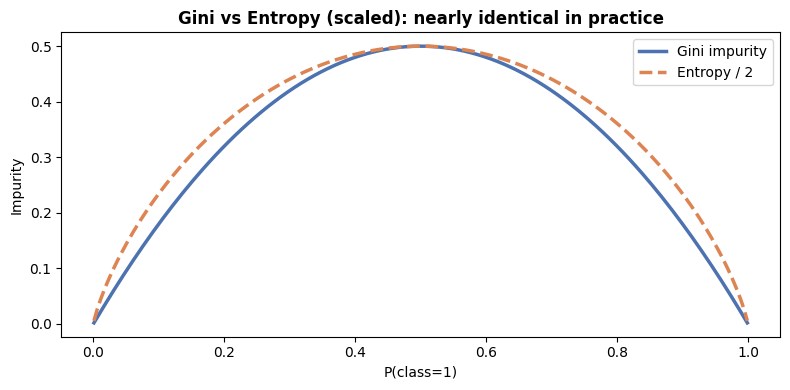

Pure node   — Gini: 0.0000  Entropy: -0.0000
50/50 split — Gini: 0.5000  Entropy: 1.0000


In [2]:
p = np.linspace(0.001, 0.999, 200)
gini_vals    = 1 - (p**2 + (1-p)**2)
entropy_vals = -(p*np.log2(p) + (1-p)*np.log2(1-p))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p, gini_vals,         label='Gini impurity', linewidth=2.5, color='#4C72B0')
ax.plot(p, entropy_vals / 2,  label='Entropy / 2',   linewidth=2.5, color='#DD8452', linestyle='--')
ax.set_xlabel('P(class=1)'); ax.set_ylabel('Impurity')
ax.set_title('Gini vs Entropy (scaled): nearly identical in practice', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# Verify our implementations
y_pure  = np.array([1, 1, 1, 1])
y_mixed = np.array([0, 0, 1, 1])
print(f"Pure node   — Gini: {gini_impurity(y_pure):.4f}  Entropy: {entropy(y_pure):.4f}")
print(f"50/50 split — Gini: {gini_impurity(y_mixed):.4f}  Entropy: {entropy(y_mixed):.4f}")


## 2. How Splits Are Chosen

For each feature and each threshold candidate:
```
information_gain = parent_impurity - (n_left/n * impurity_left + n_right/n * impurity_right)
```
We pick the (feature, threshold) pair that maximises information gain.


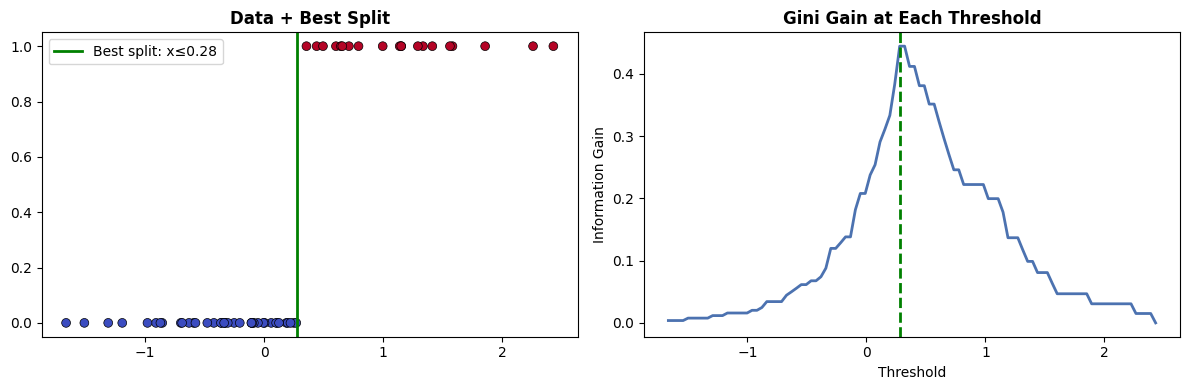

Best threshold: 0.280, Gain: 0.4444


In [3]:
# Visualize split selection on 1D data
np.random.seed(5)
X_1d = np.random.randn(60, 1)
y_1d = (X_1d[:, 0] > 0.3).astype(int)

thresholds = np.linspace(X_1d.min(), X_1d.max(), 100)
gains = []
parent_imp = gini_impurity(y_1d)

for t in thresholds:
    left  = y_1d[X_1d[:, 0] <= t]
    right = y_1d[X_1d[:, 0] >  t]
    if len(left) == 0 or len(right) == 0:
        gains.append(0); continue
    n = len(y_1d)
    weighted = (len(left)/n * gini_impurity(left) + len(right)/n * gini_impurity(right))
    gains.append(parent_imp - weighted)

best_t = thresholds[np.argmax(gains)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(X_1d, y_1d, c=y_1d, cmap='coolwarm', s=40, edgecolors='k', linewidths=0.5)
ax1.axvline(best_t, color='green', linewidth=2, label=f'Best split: x≤{best_t:.2f}')
ax1.set_title('Data + Best Split', fontweight='bold'); ax1.legend()

ax2.plot(thresholds, gains, color='#4C72B0', linewidth=2)
ax2.axvline(best_t, color='green', linewidth=2, linestyle='--')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('Information Gain')
ax2.set_title('Gini Gain at Each Threshold', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Best threshold: {best_t:.3f}, Gain: {max(gains):.4f}")


## 3. Depth vs Overfitting

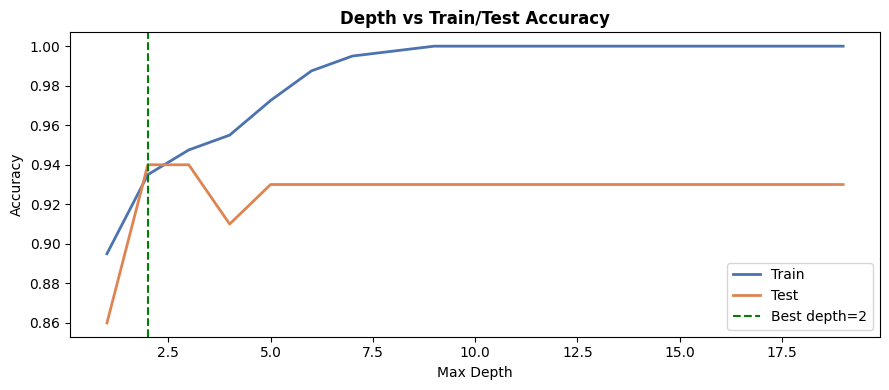

Best depth=2: train=0.935, test=0.940


In [4]:
X, y = make_classification(n_samples=500, n_features=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

depths = range(1, 20)
train_accs, test_accs = [], []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_tr, y_tr)
    train_accs.append(dt.score(X_tr, y_tr))
    test_accs.append(dt.score(X_te, y_te))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(depths), train_accs, label='Train', color='#4C72B0', linewidth=2)
ax.plot(list(depths), test_accs,  label='Test',  color='#DD8452', linewidth=2)
best_d = list(depths)[np.argmax(test_accs)]
ax.axvline(best_d, color='green', linestyle='--', label=f'Best depth={best_d}')
ax.set_xlabel('Max Depth'); ax.set_ylabel('Accuracy')
ax.set_title('Depth vs Train/Test Accuracy', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Best depth={best_d}: train={train_accs[best_d-1]:.3f}, test={test_accs[best_d-1]:.3f}")


## 4. Feature Importance

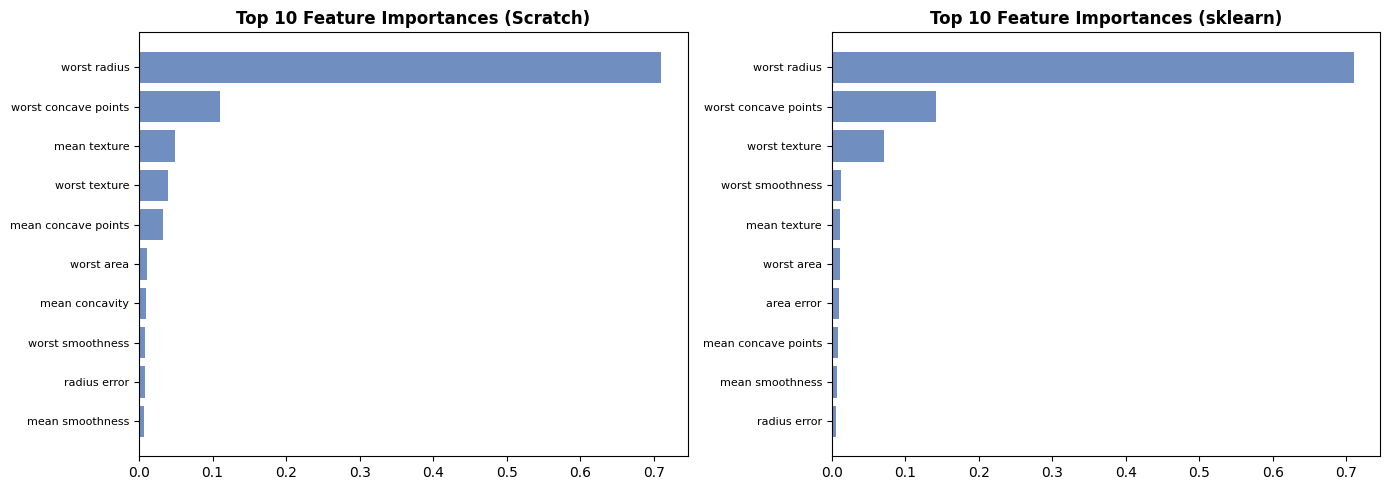

Correlation between scratch and sklearn importances:  0.9957


In [6]:
from sklearn.datasets import load_breast_cancer
X_bc, y_bc = load_breast_cancer(return_X_y=True)
feature_names = load_breast_cancer().feature_names

dt = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_bc, y_bc)
sk = SKTree(max_depth=5, random_state=42).fit(X_bc, y_bc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp, title in [(ax1, dt.feature_importances_, 'Scratch'),
                        (ax2, sk.feature_importances_, 'sklearn')]:
    idx = np.argsort(imp)[-10:]
    ax.barh(range(10), imp[idx], color='#4C72B0', alpha=0.8)
    ax.set_yticks(range(10)); ax.set_yticklabels(feature_names[idx], fontsize=8)
    ax.set_title(f'Top 10 Feature Importances ({title})', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Correlation between scratch and sklearn importances: ", f"{np.corrcoef(dt.feature_importances_, sk.feature_importances_)[0,1]:.4f}")


## 5. Sklearn Validation

In [ ]:
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_bc, y_bc, test_size=0.2, random_state=0)
my = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_tr2, y_tr2)
sk = SKTree(max_depth=4, random_state=42).fit(X_tr2, y_tr2)
print(f"My accuracy: {my.score(X_te2, y_te2):.4f}")
print(f"SK accuracy: {sk.score(X_te2, y_te2):.4f}")
print(f"Difference:  {abs(my.score(X_te2, y_te2) - sk.score(X_te2, y_te2)):.4f}")
print("(Small differences are expected due to tie-breaking in split selection)")

My accuracy: 0.9561
SK accuracy: 0.9561
Difference:  0.0000
(Small differences are expected due to tie-breaking in split selection)
